# A whole phase space, evolving through time

`trig_art.ipynb` does something the [irrational_trig](irrational_trig.ipynb) notebook doesn't: instead of tracing one point or one curve, it evaluates a trig-built scalar field over an *entire 2D grid* -- `Z(x, y)` for every `(x, y)` at once -- and animates the whole field as a phase parameter advances. This notebook does the same thing, but built specifically out of irrational numbers instead of an arbitrary formula, so the "why does it look like that" has an actual answer.

**The construction: a sum of plane waves.**

$$Z(x, y, t) = \sum_{i=0}^{N-1} \cos\big(x\cos\theta_i + y\sin\theta_i + s_i t\big)$$

Each term is a flat wave traveling in direction $\theta_i$. Two things determine everything about how this looks and moves:

- **The directions** $\theta_i = i \cdot 2\pi/N$ are evenly spaced around the circle. For $N \le 4$ or $N = 6$ this reduces to an ordinary periodic wallpaper pattern. For $N = 5$ or $N = 7$ (used here) the *crystallographic restriction theorem* says no periodic tiling can have that symmetry -- so the interference pattern is forced to be a genuine **quasicrystal**: locally so structured it looks like it must repeat, globally never quite doing so.
- **The speeds** $s_i$ are what make this notebook belong next to the last one. If the speeds are commensurate (rational multiples of each other -- say the integers 1..7) the whole field is exactly periodic in time: it returns to a past frame after one shared period. If the speeds are *N* numbers with no common rational relationship -- here, seven honest irrationals: $\varphi$, $\sqrt2$, $e$, $\pi$, $\sqrt3$, $\sqrt5$, $\ln 2$ -- the field is a **quasiperiodic flow on an N-torus**: the direct generalization of the two-frequency Lissajous curves from the last notebook to seven frequencies at once. Watched forever, it never shows you the same frame twice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from IPython.display import Image as IPImage

GOLDEN = (1 + 5 ** 0.5) / 2

N_WAVES = 7
IRRATIONAL_SPEEDS = [GOLDEN, np.sqrt(2), np.e, np.pi, np.sqrt(3), np.sqrt(5), np.log(2)]
RATIONAL_SPEEDS = list(range(1, N_WAVES + 1))  # control: exact integers, exactly commensurate

def quasi_field(X, Y, t, speeds):
    """Sum of N plane waves, evenly spaced in direction, each with its own time-speed."""
    n = len(speeds)
    Z = np.zeros_like(X)
    for i, speed in enumerate(speeds):
        theta = 2 * np.pi * i / n
        Z += np.cos(X * np.cos(theta) + Y * np.sin(theta) + speed * t)
    return Z

extent = 15
x = np.linspace(-extent, extent, 320)
y = np.linspace(-extent, extent, 320)
X, Y = np.meshgrid(x, y)

## One instant of the phase space

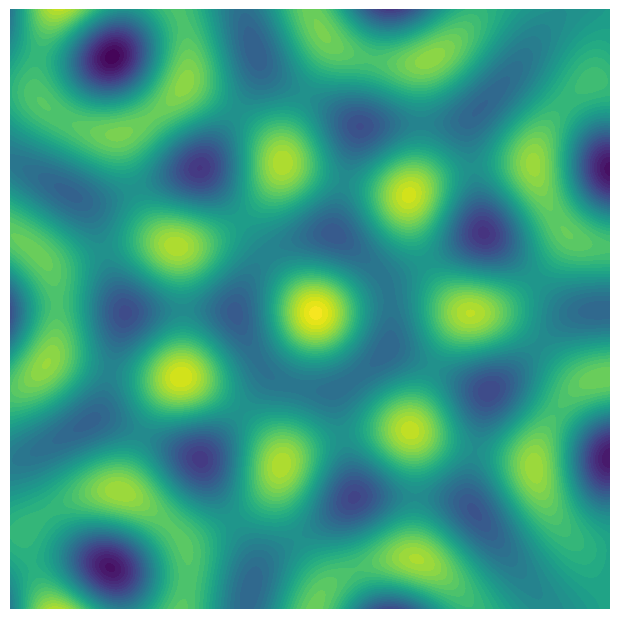

In [5]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.contourf(X, Y, quasi_field(X, Y, 0.4, IRRATIONAL_SPEEDS), levels=40, cmap="viridis")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
ax.axis("off")
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig("quasicrystal_field.png", dpi=100, bbox_inches="tight", pad_inches=0)
plt.show()

Seven-fold rosettes, tiling outward, never quite settling into a repeating grid -- that's the crystallographic restriction at work, and it doesn't care whether the speeds are rational or irrational. The speeds only control what happens next: whether this exact picture ever comes back.

## Does it ever repeat?

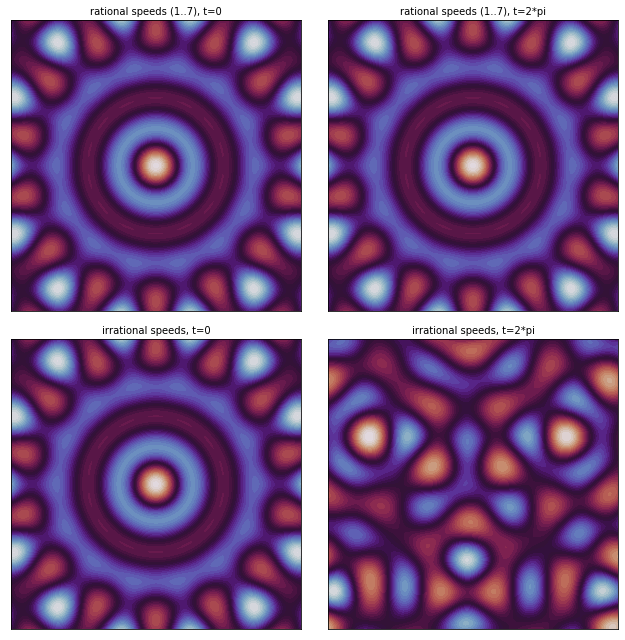

In [6]:
T = 2 * np.pi  # the rational control's shared period: speed*T = 2*pi*integer for every integer speed

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
panels = [
    ("rational speeds (1..7), t=0", RATIONAL_SPEEDS, 0.0),
    ("rational speeds (1..7), t=2*pi", RATIONAL_SPEEDS, T),
    ("irrational speeds, t=0", IRRATIONAL_SPEEDS, 0.0),
    ("irrational speeds, t=2*pi", IRRATIONAL_SPEEDS, T),
]
for ax, (title, speeds, t) in zip(axes.flat, panels):
    ax.contourf(X, Y, quasi_field(X, Y, t, speeds), levels=40, cmap="twilight")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.savefig("period_comparison.png", dpi=120)
plt.show()

The rational-speed field is pixel-for-pixel the same picture at `t=0` and `t=2*pi` -- every wave completed a whole number of cycles, so the whole sum landed back where it started. The irrational-speed field is a visibly different picture at the same two times: with seven mutually irrational speeds there is no shared period for all of them to land back on together, so `t=2*pi` catches it somewhere it has never been before, and it never gets a second chance to repeat exactly.

## Watch it evolve: the irrational field animated

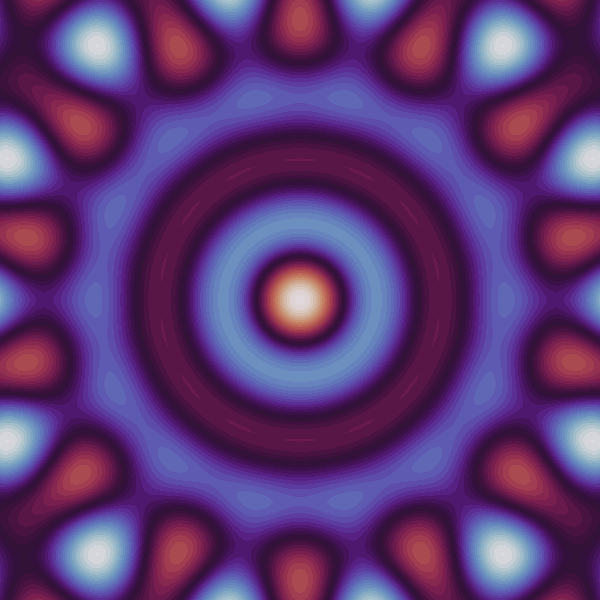

In [7]:
t_values = np.linspace(0, 4 * np.pi, 50)
frames = []

for t in t_values:
    Z = quasi_field(X, Y, t, IRRATIONAL_SPEEDS)

    fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
    ax.contourf(X, Y, Z, levels=40, cmap="twilight")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.axis("off")
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
    buf.seek(0)
    frames.append(Image.open(buf).convert("RGB"))
    plt.close(fig)

gif_path = "quasicrystal_flow.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=90, loop=0)
IPImage(filename=gif_path)

## Takeaways

- `trig_art.ipynb`'s trick -- evaluate a field over the whole plane, animate a phase -- generalizes cleanly to fields built from a sum of directional waves, and irrational numbers get to play two independent roles in it.
- The **spatial** aperiodicity (the quasicrystal look) comes from using 5 or 7 evenly-spaced directions, a consequence of the crystallographic restriction theorem -- rational, not irrational, in origin.
- The **temporal** aperiodicity -- the animation never repeating a frame -- comes from giving the waves mutually irrational speeds, which is exactly the multi-frequency version of the two-frequency Lissajous argument from the last notebook: a quasiperiodic flow on an N-torus instead of a 2-torus.
- Swap `RATIONAL_SPEEDS` in for `IRRATIONAL_SPEEDS` in the animation cell and it'll loop perfectly after 50 frames -- worth trying, to feel the difference rather than just read about it.